# Import libraries

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load full ground truth

In [2]:
def load_gt(gt_fname):
    with open(gt_fname) as f:
        gt = json.load(f)

    rows_gt = []
    for video_id, info in gt["database"].items():
        duration = info["duration"]
        subset = info["subset"]
        for s in info["annotations"]:
            rows_gt.append(
                {
                    "video_id": video_id,
                    "duration": duration,
                    "subset": subset,
                    "start": s["segment"][0],
                    "end": s["segment"][1],
                    "label": s["label"],
                }
            )

    return pd.DataFrame(rows_gt)

In [3]:
gt_df = load_gt("../data/charades/annotations/charades.json")

# Function to generate sample charades

In [4]:
def build_sample_dataset(
    sample_gt_df,
    category_idx_fname="../data/charades/annotations/sample_category_idx.txt",
    gt_fname="../data/charades/annotations/sample_charades.json",
):  
    # Save category index to a text file
    actions = sorted(sample_gt_df["label"].unique().tolist())
    with open(category_idx_fname, "w") as f:
        for action in actions:
            f.write(action + "\n")

    # Save sample annotations to JSON file
    output = {"version": "Charades_v1_Sample", "database": {}}

    for video_id, group in sample_gt_df.groupby("video_id"):
        # keep duration/subset from the original gt
        duration = sample_gt_df[sample_gt_df["video_id"] == video_id]["duration"].iloc[0]
        subset = sample_gt_df[sample_gt_df["video_id"] == video_id]["subset"].iloc[0]

        annotations = []
        for _, row in group.iterrows():
            annotations.append(
                {"segment": [row["start"], row["end"]], "label": row["label"]}
            )
        output["database"][video_id] = {
            "duration": duration,
            "subset": subset,
            "annotations": annotations,
        }

    with open(gt_fname, "w") as f:
        json.dump(output, f, indent=2)

### Sample the 10 least frequent classes

In [5]:
# Create sample classes and save them to a file
least_sample_classes = sorted(
    gt_df["label"].value_counts()[-10:].index.tolist()
)  # Select the 10 least frequent classes

least_sample_gt_df = gt_df[gt_df["label"].isin(least_sample_classes)].copy()

build_sample_dataset(
    least_sample_gt_df,
    category_idx_fname="../data/charades/annotations/least_sample_category_idx.txt",
    gt_fname="../data/charades/annotations/least_sample_charades.json",
)

In [6]:
least_sample_gt_df.shape

(449, 6)

In [9]:
least_sample_gt_df['video_id'].unique().shape

(423,)

<Axes: title={'center': 'Number of videos per class in the least sample ground truth - training subset'}, xlabel='label'>

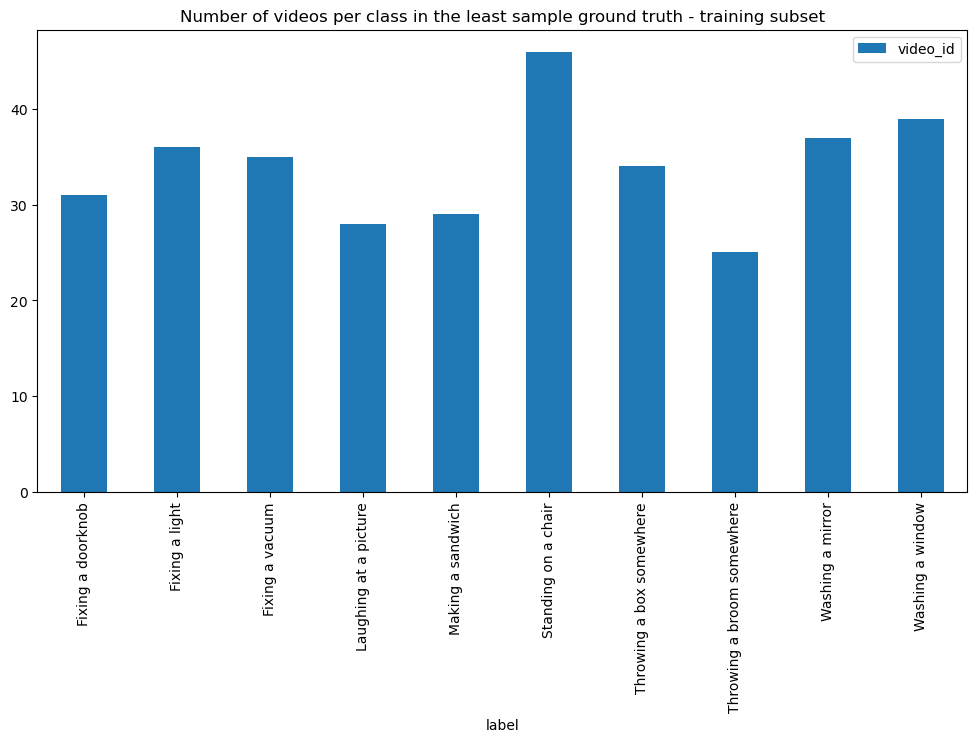

In [111]:
# Explore the sample ground truth
least_sample_gt_df = load_gt("../data/charades/annotations/least_sample_charades.json")

least_sample_gt_df[least_sample_gt_df["subset"] == "training"].groupby("label").agg(
    {"video_id": "nunique"},
).plot(
    kind="bar",
    figsize=(12, 6),
    title="Number of videos per class in the least sample ground truth - training subset",
)

<Axes: title={'center': 'Number of videos per class in the least sample ground truth - testing subset'}, xlabel='label'>

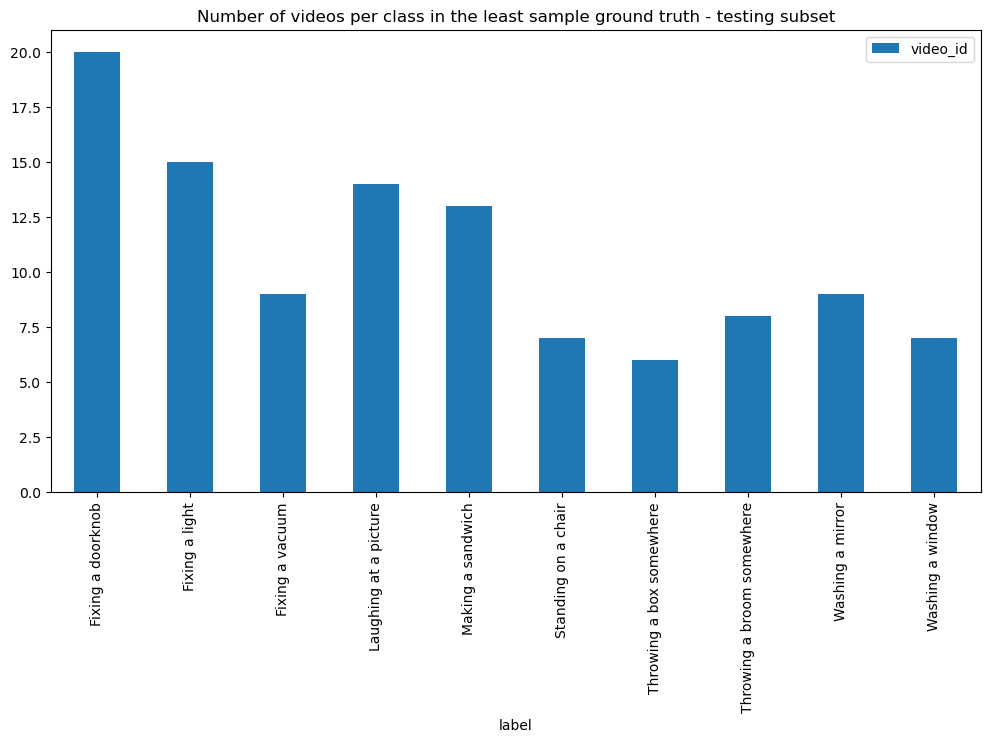

In [112]:
least_sample_gt_df[least_sample_gt_df["subset"] == "testing"].groupby("label").agg(
    {"video_id": "nunique"}
).plot(
    kind="bar",
    figsize=(12, 6),
    title="Number of videos per class in the least sample ground truth - testing subset",
)

### Sample the 10 most frequent classes (200 segments for each class) - main

In [129]:
# Create sample classes and save them to a file
most_sample_classes = sorted(
    gt_df["label"].value_counts()[:10].index.tolist()
)  # Select the 10 most frequent classes

# Step 0: Filter the original dataset to include only the most frequent classes
most_gt_df = gt_df[gt_df["label"].isin(most_sample_classes)].copy()

# Step 1: Sample ~200 rows per label from the filtered dataset
most_sample_rows = most_gt_df.groupby('label', group_keys=False).sample(n=200, random_state=42).copy()

# Step 2: Get all unique video_ids from those sampled rows
video_ids_to_include = most_sample_rows["video_id"].unique()

# Step 3: Filter the original df to include all rows with those video_ids
most_sample_gt_df = most_gt_df[most_gt_df["video_id"].isin(video_ids_to_include)].copy()

build_sample_dataset(
    most_sample_gt_df,
    category_idx_fname="../data/charades/annotations/most_sample_category_idx.txt",
    gt_fname="../data/charades/annotations/most_sample_charades.json",
)

In [130]:
most_sample_gt_df.sample(10)

,video_id,duration,subset,start,end,label
34625,SAO1A,13.46,testing,3.5,13.5,Holding a cup/glass/bottle of something
35707,BLPAB,30.46,training,0.0,31.0,Sitting in a chair
66362,PEWH4,31.62,testing,9.7,24.5,Someone is eating something
60278,W4U3V,36.88,training,11.5,18.6,Drinking from a cup/glass/bottle
12232,VSO80,31.50,training,7.8,32.0,Holding some food
38189,8AKGE,26.96,training,14.6,25.6,Drinking from a cup/glass/bottle
14008,O7N6K,22.00,training,0.3,7.1,Walking through a doorway
35564,FB3ZG,19.50,testing,0.0,12.6,Someone is standing up from somewhere
65337,I0IW5,17.54,training,2.3,7.7,Walking through a doorway
49892,7XVS7,39.12,training,27.4,32.6,Drinking from a cup/glass/bottle


<Axes: title={'center': 'Number of videos per class in the most sample ground truth - training subset'}, xlabel='label'>

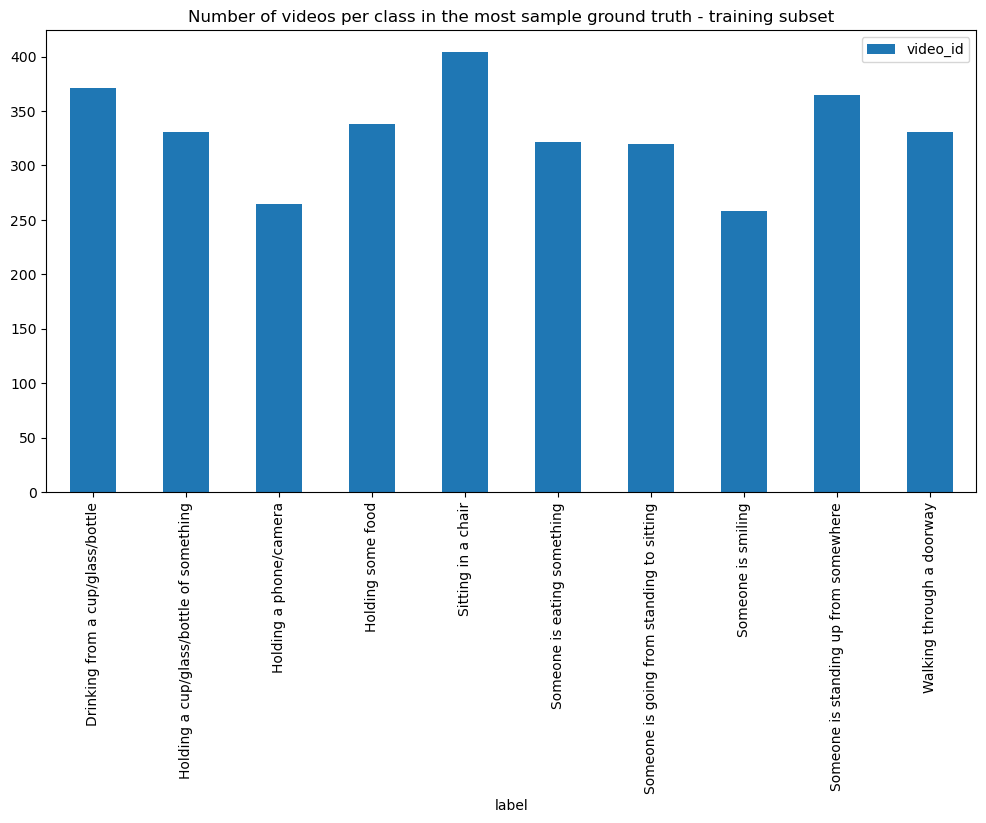

In [131]:
# Explore the sample ground truth
most_sample_gt_df = load_gt("../data/charades/annotations/most_sample_charades.json")

most_sample_gt_df[most_sample_gt_df["subset"] == "training"].groupby("label").agg(
    {"video_id": "nunique"}
).plot(
    kind="bar",
    figsize=(12, 6),
    title="Number of videos per class in the most sample ground truth - training subset",
)

In [132]:
most_sample_gt_df[most_sample_gt_df["subset"] == "training"].shape

(3404, 6)

<Axes: title={'center': 'Number of videos per class in the most sample ground truth - testing subset'}, xlabel='label'>

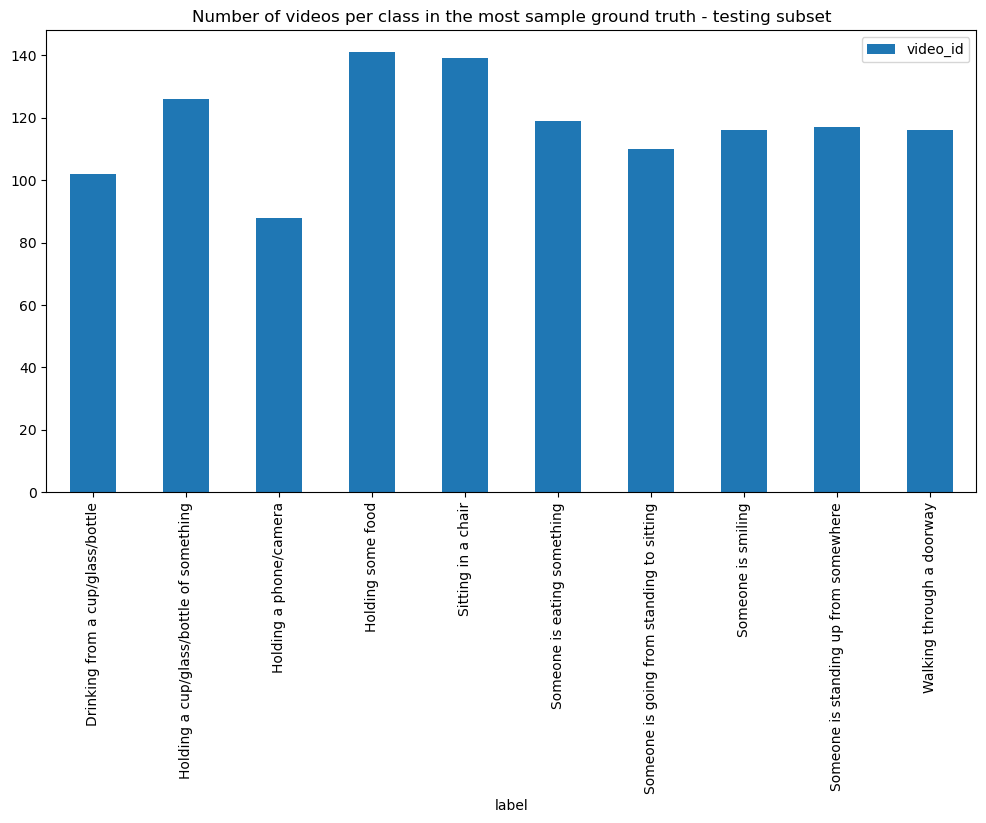

In [133]:
most_sample_gt_df[most_sample_gt_df["subset"] == "testing"].groupby("label").agg(
    {"video_id": "nunique"}
).plot(
    kind="bar",
    figsize=(12, 6),
    title="Number of videos per class in the most sample ground truth - testing subset",
)

In [134]:
most_sample_gt_df[most_sample_gt_df["subset"] == "testing"].shape

(1209, 6)

# Checking if the sample covers the population

In [137]:
most_sample_gt_df.sample(5)

,video_id,duration,subset,start,end,label
4257,X29NF,42.79,training,13.4,23.6,Someone is eating something
3404,RF4OI,26.58,training,0.4,6.0,Drinking from a cup/glass/bottle
3471,RZDEA,28.83,training,6.7,14.6,Someone is smiling
820,6KDQO,29.79,training,21.3,27.5,Someone is standing up from somewhere
3398,RDHNQ,37.38,training,0.0,6.5,Walking through a doorway


In [142]:
most_sample_gt_df[most_sample_gt_df['video_id'] == '6KDQO']

,video_id,duration,subset,start,end,label
820,6KDQO,29.79,training,21.3,27.5,Someone is standing up from somewhere
821,6KDQO,29.79,training,9.9,18.6,Drinking from a cup/glass/bottle
822,6KDQO,29.79,training,4.9,10.5,Someone is going from standing to sitting
823,6KDQO,29.79,training,6.7,24.4,Sitting in a chair
824,6KDQO,29.79,training,2.2,28.0,Holding some food


In [143]:
gt_df[(gt_df['video_id'] == '6KDQO') & (gt_df['label'].isin(most_sample_classes))]

,video_id,duration,subset,start,end,label
17549,6KDQO,29.79,training,21.3,27.5,Someone is standing up from somewhere
17550,6KDQO,29.79,training,9.9,18.6,Drinking from a cup/glass/bottle
17552,6KDQO,29.79,training,4.9,10.5,Someone is going from standing to sitting
17553,6KDQO,29.79,training,6.7,24.4,Sitting in a chair
17555,6KDQO,29.79,training,2.2,28.0,Holding some food
